# Is Causal Factor Investing Worth It? Replication notebook

Federico M. Glancszpigel, September 2026. Reproduces every number and figure in the Medium article of the same name, end to end, from public data.

**What it does.** Compares an associational factor model (t-stat screen) with a causal one (López de Prado–Zoonekynd protocol: PC graph, adjust each premium for its causal parents, stability test) on 142 value-weighted JKP factors with publication-date eligibility and trading costs; runs the pre-registered placebos (random factor sets, random graphs, shuffled arrows); runs the control test (simulated market with a known causal graph); and finishes with validation checks and an audit of the article's numbers.

**Data (downloaded automatically, ~2.5 MB):** JKP US factors, capped value-weighted, and factor metadata from `github.com/bkelly-lab/jkp-data`; market excess return and the first-universe OSAP factors from `github.com/fedeglan/PAPER-The-Stationarity-Assumption-Is-Free`.

**Runtime:** about 20 minutes on one core with `FAST = False`; about 3 minutes with `FAST = True` (primary settings only, fewer placebo draws; the audit then checks only the primary numbers). Intermediate results are cached in `cache/`, so an interrupted run resumes where it stopped.

**Requirements:** `numpy pandas scipy scikit-learn matplotlib networkx openpyxl pyarrow causal-learn`.

In [1]:
FAST = False          # True = smoke test (primary settings only, fewer draws)
DATA_DIR = 'data'
FIG_DIR = 'figures'
CACHE_DIR = 'cache'   # intermediate results; delete it to recompute from scratch
N_RANDK = 20 if FAST else 200      # random factor-set placebo draws
N_RGRAPH = 10 if FAST else 40      # random graph / random orientation draws per seed (two seeds)
N_LAB = 20 if FAST else 200        # control-test replications

import os, time, itertools, urllib.request, warnings, pickle
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import nnls, minimize
from scipy.linalg import solve_triangular
from scipy.stats import norm, skew, kurtosis
from sklearn.covariance import LedoitWolf
warnings.filterwarnings('ignore')
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(CACHE_DIR, exist_ok=True)
def cached(name, fn):
    '''Resumable runs: results are stored on disk and reused if the notebook is re-run.'''
    p = f'{CACHE_DIR}/{name}.pkl'
    if os.path.exists(p):
        return pickle.load(open(p, 'rb'))
    v = fn(); pickle.dump(v, open(p + '.tmp', 'wb')); os.replace(p + '.tmp', p); return v
T0 = time.time()

## 1. Data
JKP factors are long top tercile minus bottom tercile, weighted by market cap winsorized at the NYSE 80th percentile, signed in the published direction. Publication years come from the `cite` field of JKP's `factor_details.xlsx`; the 11 factors without a year are dropped from the realistic universe.

In [2]:
URLS = {
    'jkp.parquet': 'https://raw.githubusercontent.com/bkelly-lab/jkp-data/main/documentation/sas_to_python/data/US_factors_SAS.parquet',
    'jkp_py.parquet': 'https://raw.githubusercontent.com/bkelly-lab/jkp-data/main/documentation/sas_to_python/data/US_factors_py.parquet',
    'factor_details.xlsx': 'https://raw.githubusercontent.com/bkelly-lab/jkp-data/main/src/jkp/data/resources/factor_details.xlsx',
    'ff6.parquet': 'https://raw.githubusercontent.com/fedeglan/PAPER-The-Stationarity-Assumption-Is-Free/main/data/processed/ff6_factors.parquet',
    'osap.parquet': 'https://raw.githubusercontent.com/fedeglan/PAPER-The-Stationarity-Assumption-Is-Free/main/data/processed/osap_factors.parquet'}
for f, u in URLS.items():
    p = os.path.join(DATA_DIR, f)
    if not os.path.exists(p):
        urllib.request.urlretrieve(u, p)

ff = pd.read_parquet(f'{DATA_DIR}/ff6.parquet'); ff.index = ff.index.to_period('M')
osap = pd.read_parquet(f'{DATA_DIR}/osap.parquet'); osap.index = osap.index.to_period('M')
S = pd.read_parquet(f'{DATA_DIR}/jkp.parquet'); S['date'] = pd.to_datetime(S['date']).dt.to_period('M')
JKP = S.pivot(index='date', columns='name', values='ret')
SPAN_ = (pd.Period('1963-07', 'M'), pd.Period('2024-12', 'M'))
MKT = 'Mkt-RF'
U68 = ff.drop(columns='RF').join(osap, how='inner').loc[SPAN_[0]:SPAN_[1]]          # first universe
J153 = U68[[MKT]].join(JKP, how='inner').loc[SPAN_[0]:SPAN_[1]]                      # JKP, no dates
X = pd.read_excel(f'{DATA_DIR}/factor_details.xlsx').dropna(subset=['abr_jkp'])
X['year'] = X['cite'].astype(str).str.extract(r'\((\d{4})')[0].astype(float)
PUB = X.drop_duplicates('abr_jkp').set_index('abr_jkp')['year'].dropna().to_dict()
JP = J153[[c for c in J153.columns if c == MKT or c in PUB]]                          # realistic universe
yrs = pd.Series({c: PUB[c] for c in JP.columns if c != MKT})
print(U68.shape, J153.shape, JP.shape)
print(f'dated factors {len(yrs)}; published before 1983: {(yrs < 1983).sum()}, before 2000: {(yrs < 2000).sum()}, median year {yrs.median():.0f}')

(738, 68) (738, 154) (738, 143)
dated factors 142; published before 1983: 5, before 2000: 35, median year 2006


## 2. Fast PC algorithm
A vectorized re-implementation of causal-learn's PC (stable, Fisher-z, max conditioning set 3, collider priority rule 2, Meek rules, background knowledge that nothing points into the market). Section 9 checks it against causal-learn. Encoding: `g[i,j] = -1` and `g[j,i] = 1` means `i -> j`; both `-1` means `i -- j`.

In [3]:
def _skeleton(C, n, alpha, max_k):
    p = C.shape[0]; adj = np.ones((p, p), bool); np.fill_diagonal(adj, False); sep = {}; depth = -1
    while adj.sum(1).max() - 1 > depth:
        depth += 1
        if max_k is not None and depth > max_k: break
        thr = norm.ppf(1 - alpha / 2) / np.sqrt(n - depth - 3); A = adj.copy(); removal = set()
        for x in range(p):
            Nx = np.where(A[x])[0]
            for y in Nx:
                cand = Nx[Nx != y]
                if len(cand) < depth: continue
                if depth == 0:
                    r = np.array([C[x, y]]); combos = np.zeros((1, 0), int)
                else:
                    combos = np.array(list(itertools.combinations(cand, depth)))
                    idx = np.column_stack([np.full(len(combos), x), np.full(len(combos), y), combos])
                    P = np.linalg.inv(C[idx[:, :, None], idx[:, None, :]])
                    r = -P[:, 0, 1] / np.sqrt(P[:, 0, 0] * P[:, 1, 1])
                ind = np.abs(np.arctanh(np.clip(r, -0.9999999, 0.9999999))) <= thr
                if ind.any():
                    removal.add((x, y)); removal.add((y, x))
                    s = tuple(sorted(set(combos[ind].ravel().tolist())))
                    sep.setdefault((x, y), []).append(s); sep.setdefault((y, x), []).append(s)
        for x, y in removal: adj[x, y] = False
    return adj, sep

def _adj_list(G):
    L = np.where(G == -1); M = np.where(G == 1)
    return list(zip(L[1].tolist(), L[0].tolist())) + list(zip(M[1].tolist(), M[0].tolist()))

def _triples(G, adjl, shielded):
    return [(a0, a1, b1) for (a0, a1) in adjl for (b0, b1) in adjl if a1 == b0 and a0 != b1 and ((G[a0, b1] != 0) == shielded)]

def pc_fast(X, alpha=0.05, max_k=3, exo=None):
    n, p = X.shape; C = np.corrcoef(X, rowvar=False); adj, sep = _skeleton(C, n, alpha, max_k)
    G = np.zeros((p, p)); G[adj] = -1
    directed = lambda a, b: G[a, b] == -1 and G[b, a] == 1
    undirected = lambda a, b: G[a, b] == -1 and G[b, a] == -1
    forbidden = lambda a, b: exo is not None and b == exo
    def set_dir(a, b): G[a, b] = -1; G[b, a] = 1
    def is_ancestor(a, b):
        seen = {a}; stack = [a]
        while stack:
            u = stack.pop()
            for v in np.where(G[u] == -1)[0]:
                if G[v, u] == 1 and v not in seen:
                    if v == b: return True
                    seen.add(v); stack.append(v)
        return False
    if exo is not None:
        for j in np.where(adj[exo])[0]: set_dir(exo, j)
    for (x, y, z) in [t for t in _triples(G, _adj_list(G), False) if t[0] < t[2]]:
        if forbidden(x, y) or forbidden(z, y): continue
        if all(y not in S_ for S_ in sep.get((x, z), [])) and not directed(y, x) and not directed(y, z):
            set_dir(x, y); set_dir(z, y)
    adjl = _adj_list(G); UT = _triples(G, adjl, False); Tri = _triples(G, adjl, True)
    Kite = [(a[0], a[1], b[1], a[2]) for a in Tri for b in Tri if a != b and a[0] == b[0] and a[2] == b[2] and a[1] < b[1] and G[a[1], b[1]] == 0]
    loop = True
    while loop:
        loop = False
        for (i, j, k) in UT:
            if directed(i, j) and undirected(j, k) and not forbidden(j, k) and not is_ancestor(k, j): set_dir(j, k); loop = True
        for (i, j, k) in Tri:
            if directed(i, j) and directed(j, k) and undirected(i, k) and not forbidden(i, k) and not is_ancestor(k, i): set_dir(i, k); loop = True
        for (i, j, k, l) in Kite:
            if undirected(i, j) and undirected(i, k) and directed(j, l) and directed(k, l) and undirected(i, l) and not forbidden(i, l) and not is_ancestor(l, i):
                set_dir(i, l); loop = True
    return G

## 3. Portfolio engine
Annual rebalance each June, OOS July 1983 to December 2024. Selection rules: `tstat` (simple model) and `dag` (causal model: premium = intercept on possible parents = directed parents plus undirected neighbours; kept if t > tau and, with `stab`, positive in both halves of the window). Constructors: long-only mean-variance (NNLS on the Cholesky factor, Ledoit-Wolf covariance) or inverse volatility, scaled to 10% ex-ante volatility. Costs: 20 bps per unit of notional reallocated, plus an internal cost per month per unit of anomaly-factor notional (the market leg is exempt).

In [4]:
REBAL = [pd.Period(f'{y}-06', 'M') for y in range(1983, 2025)]
OOS = pd.period_range('1983-07', '2024-12', freq='M')
VOL_TGT = 0.10 / np.sqrt(12)
GRAPHS = {}

def lw_cov(R): return LedoitWolf().fit(R).covariance_

def mv_long_only(mu, S):
    if len(mu) == 0 or np.all(mu <= 0): return np.zeros(len(mu))
    L = np.linalg.cholesky(S + 1e-12 * np.eye(len(mu))); w, _ = nnls(L.T, solve_triangular(L, mu, lower=True))
    v = np.sqrt(w @ S @ w); return w * VOL_TGT / v if v > 0 else w

def possible_parents(g, j):
    return [i for i in range(g.shape[0]) if i != j and g[i, j] == -1 and g[j, i] in (1, -1)]

def ols_alpha(y, Xr):
    Z = np.column_stack([np.ones(len(y)), Xr]) if Xr.shape[1] else np.ones((len(y), 1))
    coef, *_ = np.linalg.lstsq(Z, y, rcond=None); res = y - Z @ coef
    s2 = res @ res / (len(y) - Z.shape[1]); se = np.sqrt(s2 * np.linalg.inv(Z.T @ Z)[0, 0])
    return coef[0], coef[0] / se

def pc_graph(R, names, alpha, key):
    if key not in GRAPHS:
        Z = (R - R.mean(0)) / R.std(0)
        GRAPHS[key] = cached('pc_{}_W{}_a{}_{}'.format(*key), lambda: pc_fast(Z, alpha, 3, exo=names.index(MKT) if MKT in names else None))
    return GRAPHS[key]

def dag_select(R, g, tau=2, stab=True):
    T = len(R); h = T // 2; keep = []
    for j in range(R.shape[1]):
        pa = possible_parents(g, j); a, t = ols_alpha(R[:, j], R[:, pa])
        if t > tau and (not stab or (ols_alpha(R[:h, j], R[:h, pa])[0] > 0 and ols_alpha(R[h:, j], R[h:, pa])[0] > 0)):
            keep.append(j)
    return np.array(keep, int)

def tstat_select(R, tau, stab):
    T = len(R); h = T // 2; t = R.mean(0) / (R.std(0, ddof=1) / np.sqrt(T)); keep = t > tau
    if stab: keep &= (R[:h].mean(0) > 0) & (R[h:].mean(0) > 0)
    return np.where(keep)[0]

def dag_cov(R, g):
    p = R.shape[1]; D = nx.DiGraph(); D.add_nodes_from(range(p)); und = []
    for i in range(p):
        for j in range(i + 1, p):
            if g[i, j] == -1 and g[j, i] == 1: D.add_edge(i, j)
            elif g[j, i] == -1 and g[i, j] == 1: D.add_edge(j, i)
            elif g[i, j] != 0: und.append((i, j))
    while not nx.is_directed_acyclic_graph(D): D.remove_edge(*nx.find_cycle(D)[0])
    pos = {v: k for k, v in enumerate(nx.topological_sort(D))}
    for i, j in und: D.add_edge(i, j) if pos[i] < pos[j] else D.add_edge(j, i)
    B = np.zeros((p, p)); dv = np.zeros(p); Rc = R - R.mean(0)
    for j in range(p):
        pa = list(D.predecessors(j))
        if pa:
            coef, *_ = np.linalg.lstsq(Rc[:, pa], Rc[:, j], rcond=None); B[j, pa] = coef
            dv[j] = (Rc[:, j] - Rc[:, pa] @ coef).var(ddof=len(pa) + 1)
        else: dv[j] = Rc[:, j].var(ddof=1)
    A = np.linalg.inv(np.eye(p) - B); return A @ np.diag(dv) @ A.T

def walk(F, select_fn, W=240, ivol=False, elig_fn=lambda c, d: True, bench=None):
    cols = list(F.columns); gross = pd.Series(0.0, index=OOS); turn = {}; nsel = {}; Wd = {}; ks = {}
    w_prev = pd.Series(0.0, index=cols)
    for d in REBAL:
        win = F.loc[d - W + 1:d, cols]; elig = [c for c in cols if win[c].notna().all() and elig_fn(c, d)]; R = win[elig].values
        out = select_fn(d, elig, R); sel, Sfn = out if isinstance(out, tuple) else (out, None); ks[d] = len(sel)
        w = pd.Series(0.0, index=cols)
        if len(sel):
            Rs = R[:, sel]; S_ = Sfn()[np.ix_(sel, sel)] if Sfn else lw_cov(Rs)
            if bench: ws = np.ones(len(sel)); ws *= VOL_TGT / np.sqrt(ws @ S_ @ ws)
            elif ivol: ws = 1 / np.sqrt(np.diag(S_)); ws *= VOL_TGT / np.sqrt(ws @ S_ @ ws)
            else: ws = mv_long_only(Rs.mean(0), S_)
            w[[elig[i] for i in sel]] = ws
        hold = pd.period_range(d + 1, min(d + 12, OOS[-1]), freq='M')
        gross.loc[hold] = F.loc[hold, cols].fillna(0.0).values @ w.values
        turn[d] = float((w - w_prev).abs().sum()); nsel[d] = int((w > 0).sum()); Wd[d] = w[w != 0].copy(); w_prev = w
    return dict(gross=gross, turn=pd.Series(turn), nsel=pd.Series(nsel), w=Wd, k=pd.Series(ks))

def net(res, c_bps=20, ic_bps=20):
    r = res['gross'].copy()
    for d, tv in res['turn'].items():
        r.loc[d + 1] -= c_bps / 1e4 * tv
        if ic_bps:
            hold = pd.period_range(d + 1, min(d + 12, OOS[-1]), freq='M')
            r.loc[hold] -= ic_bps / 1e4 * res['w'][d].drop(MKT, errors='ignore').abs().sum()
    return r

pub_elig = lambda c, d: c == MKT or PUB.get(c, 9999) <= d.year - 1

def model_fn(tag, rule, W, tau, stab, alpha=None, sem=False):
    def f(d, elig, R):
        if rule == 'tstat': return tstat_select(R, tau, stab)
        g = pc_graph(R, elig, alpha, (tag, W, alpha, d)); sel = dag_select(R, g, tau, stab)
        return (sel, lambda: dag_cov(R, g)) if sem else sel
    return f

## 4. The pre-registered grid
8 associational and 16 causal configurations, plus 2 causal variants whose covariance comes from the graph, for each constructor. Benchmarks: equal weight over every eligible series and the market alone.

In [5]:
def grid():
    cfgs = {}
    Ws = (240,) if FAST else (120, 240); taus = (2,) if FAST else (2, 3); alphas = (0.05,) if FAST else (0.01, 0.05)
    for W in Ws:
        for tau in taus:
            for stab in (False, True):
                cfgs[f"SIMPLE{'+INV' if stab else ''}|W{W}|t{tau}"] = dict(rule='tstat', W=W, tau=tau, stab=stab)
                for a in alphas:
                    cfgs[f"CAUSAL{'' if stab else '-INV'}|W{W}|t{tau}|a{a}"] = dict(rule='dag', W=W, tau=tau, stab=stab, alpha=a)
            cfgs[f'CAUSAL-SEM|W{W}|t2|a0.05'] = dict(rule='dag', W=W, tau=2, stab=True, alpha=0.05, sem=True)
    return cfgs

RES = {}
for ctor, ivol in [('MV', False), ('IV', True)]:
    RES[ctor] = {}
    for k, c in grid().items():
        RES[ctor][k] = cached(f"res_{ctor}_{k.replace('|', '_')}", lambda: walk(JP, model_fn('JP', **c), W=c['W'], ivol=ivol, elig_fn=pub_elig))
    RES[ctor]['BENCH-EW'] = cached(f'res_{ctor}_ew', lambda: walk(JP, lambda d, e, R: np.arange(len(e)), elig_fn=pub_elig, bench=True))
    RES[ctor]['BENCH-MKT'] = cached(f'res_{ctor}_mkt', lambda: walk(JP, lambda d, e, R: np.array([e.index(MKT)]), elig_fn=pub_elig, bench=True))
    print(ctor, 'done', f'{time.time() - T0:.0f}s')
PS, PC = 'SIMPLE|W240|t2', 'CAUSAL|W240|t2|a0.05'

MV done 0s
IV done 1s


## 5. Inference tools
Sharpe ratio, paired stationary block bootstrap (Politis & Romano 1994), deflated Sharpe ratio (Bailey & López de Prado 2014), PBO by combinatorially symmetric cross-validation (Bailey, Borwein, López de Prado & Zhu 2017).

In [6]:
EULER = 0.5772156649
def sr(r, ann=True):
    r = np.asarray(r); s = r.mean() / r.std(ddof=1); return s * np.sqrt(12) if ann else s
def max_dd(r): c = np.cumsum(np.asarray(r)); return float((np.maximum.accumulate(c) - c).max())
def psr(r, sr_star_m=0.0):
    r = np.asarray(r); T = len(r); s = sr(r, False); g3 = skew(r); g4 = kurtosis(r, fisher=False)
    return float(norm.cdf((s - sr_star_m) * np.sqrt(T - 1) / np.sqrt(1 - g3 * s + (g4 - 1) / 4 * s ** 2)))
def dsr(r_best, trial_srs_m):
    N = len(trial_srs_m); v = np.var(trial_srs_m, ddof=1)
    sr0 = np.sqrt(v) * ((1 - EULER) * norm.ppf(1 - 1 / N) + EULER * norm.ppf(1 - 1 / (N * np.e)))
    return psr(r_best, sr0), sr0 * np.sqrt(12)
def boot_idx(T, B, mean_block=12, seed=0):
    rng = np.random.default_rng(seed); p = 1 / mean_block; idx = np.empty((B, T), dtype=int); idx[:, 0] = rng.integers(0, T, B)
    newb = rng.random((B, T)) < p; jumps = rng.integers(0, T, (B, T))
    for t in range(1, T): idx[:, t] = np.where(newb[:, t], jumps[:, t], (idx[:, t - 1] + 1) % T)
    return idx
def boot_dsr(a, b, B=5000, mean_block=12, seed=0):
    a = np.asarray(a); b = np.asarray(b); idx = boot_idx(len(a), B, mean_block, seed); A = a[idx]; Bm = b[idx]
    d = (A.mean(1) / A.std(1, ddof=1) - Bm.mean(1) / Bm.std(1, ddof=1)) * np.sqrt(12)
    lo, hi = np.percentile(d, [2.5, 97.5]); p = 2 * min((d <= 0).mean(), (d >= 0).mean())
    return sr(a) - sr(b), lo, hi, min(p, 1.0)
def cscv(M, S=16):
    M = np.asarray(M); T, N = M.shape; T2 = T - T % S; M = M[:T2]
    blk = M.reshape(S, T2 // S, N); s1 = blk.sum(1); s2 = (blk ** 2).sum(1); n = T2 // S; lam = []
    for comb in itertools.combinations(range(S), S // 2):
        ins = np.zeros(S, bool); ins[list(comb)] = True
        def srs(mask):
            k = mask.sum() * n; m = s1[mask].sum(0) / k; v = s2[mask].sum(0) / k - m ** 2
            return m / np.sqrt(v * k / (k - 1))
        a = srs(ins); o = srs(~ins); j = np.argmax(a); w = ((o < o[j]).sum() + 1) / (N + 1); lam.append(np.log(w / (1 - w)))
    return float((np.array(lam) <= 0).mean())

## 6. Main results (Table 1)
Primary window July 2000 to December 2024; 1983–2024 reported too. Primary pair: CAUSAL(W=240, t>2, alpha=0.05) vs SIMPLE(W=240, t>2).

In [7]:
SUMMARY = {}
for ctor in RES:
    R = RES[ctor]; S_K = [k for k in R if k.startswith('SIMPLE')]
    C_K = [k for k in R if k.startswith('CAUSAL|') or k.startswith('CAUSAL-INV')]; SEM_K = [k for k in R if k.startswith('CAUSAL-SEM')]
    for win, start in [('2000-2024', 2000), ('1983-2024', 1983)]:
        m = OOS.year >= start; NET = pd.DataFrame({k: net(v)[m] for k, v in R.items()}); w = {}
        for ic in (0, 10, 20, 30):
            w[f'SR_S_ic{ic}'] = sr(net(R[PS], 20, ic)[m]); w[f'SR_C_ic{ic}'] = sr(net(R[PC], 20, ic)[m])
        w['MKT'] = sr(NET['BENCH-MKT']); w['EW'] = sr(NET['BENCH-EW']); w['EW_gross'] = sr(net(R['BENCH-EW'], 0, 0)[m])
        w['d'], w['lo'], w['hi'], w['p'] = boot_dsr(NET[PC].values, NET[PS].values)
        pairs = []
        for k in C_K:
            p_ = k.split('|'); sk = f"SIMPLE{'+INV' if p_[0] == 'CAUSAL' else ''}|{p_[1]}|{p_[2]}"; pairs.append((k, sk))
        w['pairs_win'] = sum(sr(NET[a]) > sr(NET[b]) for a, b in pairs)
        dif = {a: NET[a] - NET[b] for a, b in pairs}; ir = {a: sr(v, False) for a, v in dif.items()}
        best = max(ir, key=ir.get); w['dsr_switch'] = dsr(dif[best].values, list(ir.values()))[0]
        w['pbo'] = cscv(NET[S_K + C_K + SEM_K].values, 16)
        w['turn_ratio'] = R[PC]['turn'].iloc[1:].mean() / R[PS]['turn'].iloc[1:].mean()
        SUMMARY[(ctor, win)] = w
T1 = pd.DataFrame({ctor: {
    'Simple / causal, no internal cost': f"{SUMMARY[(ctor,'2000-2024')]['SR_S_ic0']:.2f} / {SUMMARY[(ctor,'2000-2024')]['SR_C_ic0']:.2f}",
    'Simple / causal, 10 bps a month': f"{SUMMARY[(ctor,'2000-2024')]['SR_S_ic10']:.2f} / {SUMMARY[(ctor,'2000-2024')]['SR_C_ic10']:.2f}",
    'Simple / causal, 20 bps a month': f"{SUMMARY[(ctor,'2000-2024')]['SR_S_ic20']:.2f} / {SUMMARY[(ctor,'2000-2024')]['SR_C_ic20']:.2f}",
    'Difference at 20 bps, 95% CI': "{:+.2f} [{:+.2f}, {:+.2f}]".format(*[SUMMARY[(ctor,'2000-2024')][k] for k in ('d', 'lo', 'hi')]),
    'Matched configurations won by causal': f"{SUMMARY[(ctor,'2000-2024')]['pairs_win']} of {len([k for k in RES[ctor] if k.startswith('CAUSAL|') or k.startswith('CAUSAL-INV')])}",
    'Deflated Sharpe, best causal switch': f"{SUMMARY[(ctor,'2000-2024')]['dsr_switch']:.2f}",
    'PBO': f"{SUMMARY[(ctor,'2000-2024')]['pbo']:.2f}",
    'Turnover, causal / simple': f"{SUMMARY[(ctor,'2000-2024')]['turn_ratio']:.1f}x",
    'Difference 1983-2024': f"{SUMMARY[(ctor,'1983-2024')]['d']:+.2f}"} for ctor in ('MV', 'IV')})
print(f"Market 2000-2024: {SUMMARY[('MV','2000-2024')]['MKT']:.2f}; EW all published factors: gross {SUMMARY[('MV','2000-2024')]['EW_gross']:.2f}, net {SUMMARY[('MV','2000-2024')]['EW']:.2f}")
T1

Market 2000-2024: 0.43; EW all published factors: gross 0.57, net 0.11


,MV,IV
"Simple / causal, no internal cost",1.08 / 0.90,0.74 / 0.69
"Simple / causal, 10 bps a month",0.46 / 0.31,0.35 / 0.31
"Simple / causal, 20 bps a month",-0.16 / -0.29,-0.04 / -0.06
"Difference at 20 bps, 95% CI","-0.13 [-0.34, +0.11]","-0.02 [-0.26, +0.20]"
Matched configurations won by causal,10 of 16,12 of 16
"Deflated Sharpe, best causal switch",0.31,0.60
PBO,0.63,0.29
"Turnover, causal / simple",1.5x,1.8x
Difference 1983-2024,-0.11,-0.10


## 7. Attribution diagnostics (pre-registered)
Random factor sets of the causal model's size (seed 0), PC skeleton with shuffled arrows (seeds 7 and 47), random graphs with the same edge count (seeds 13 and 53), the undirected skeleton, adjustment for every other factor, and (validation) oriented parents only.

In [8]:
def to_cl(adj):
    g = np.zeros(adj.shape); i, j = np.where(adj); g[i, j] = -1; g[j, i] = 1; return g
def pcg(d, elig, R): return pc_graph(R, elig, 0.05, ('JP', 240, 0.05, d))
def f_rorient(rng):
    def f(d, elig, R):
        g = pcg(d, elig, R); p = len(elig); skel = (g != 0) & (g.T != 0)
        order = rng.permutation(p); pos = np.empty(p, int); pos[order] = np.arange(p)
        return dag_select(R, to_cl(skel & (pos[:, None] < pos[None, :])))
    return f
def f_rdag(rng):
    def f(d, elig, R):
        g = pcg(d, elig, R); p = len(elig); ne = int(((g != 0) & (g.T != 0)).sum() / 2)
        iu = np.array(np.triu_indices(p, 1)).T; pick = iu[rng.choice(len(iu), ne, replace=False)]
        order = rng.permutation(p); adj = np.zeros((p, p), bool)
        for a, b in pick: adj[order[a], order[b]] = True
        return dag_select(R, to_cl(adj))
    return f
def f_neigh(d, elig, R):
    g = pcg(d, elig, R); und = np.zeros(g.shape); und[(g != 0) & (g.T != 0)] = -1; return dag_select(R, und)
def f_span(d, elig, R):
    return np.array([j for j in range(R.shape[1]) if ols_alpha(R[:, j], R[:, [i for i in range(R.shape[1]) if i != j]])[1] > 2], int)
def f_dironly(d, elig, R):
    g = pcg(d, elig, R); return dag_select(R, np.where((g == -1) & (g.T == 1), g, 0.0) + np.where((g.T == -1) & (g == 1), g, 0.0))
DIAG = {}
for ctor, ivol in [('MV', False), ('IV', True)]:
    D = {}; K = RES[ctor][PC]['k']
    def randk():
        rng = np.random.default_rng(0)
        return [walk(JP, lambda d, e, R: rng.choice(len(e), min(K[d], len(e)), replace=False), ivol=ivol, elig_fn=pub_elig) for _ in range(N_RANDK)]
    D['RANDK'] = cached(f'diag_{ctor}_RANDK_{N_RANDK}', randk)
    D['RORIENT'] = []; D['RDAG'] = []
    for nm, fgen, seeds in [('RORIENT', f_rorient, (7, 47)), ('RDAG', f_rdag, (13, 53))]:
        for s in seeds:
            def draws(s=s, fgen=fgen):
                rng = np.random.default_rng(s); return [walk(JP, fgen(rng), ivol=ivol, elig_fn=pub_elig) for _ in range(N_RGRAPH)]
            D[nm] += cached(f'diag_{ctor}_{nm}_{s}_{N_RGRAPH}', draws)
    for nm, f in [('NEIGH', f_neigh), ('SPAN', f_span), ('DIRONLY', f_dironly)]:
        D[nm] = [cached(f'diag_{ctor}_{nm}', lambda f=f: walk(JP, f, ivol=ivol, elig_fn=pub_elig))]
    DIAG[ctor] = D; print(ctor, 'placebos done', f'{time.time() - T0:.0f}s')
m00 = OOS.year >= 2000; rows = []
for ctor in DIAG:
    sc = sr(net(RES[ctor][PC])[m00]); ss = sr(net(RES[ctor][PS])[m00])
    for nm, lst in DIAG[ctor].items():
        v = np.array([sr(net(x)[m00]) for x in lst])
        rows.append(dict(ctor=ctor, diag=nm, n=len(v), median=np.median(v), causal_pct=(v < sc).mean(), simple_pct=(v < ss).mean()))
ATTR = pd.DataFrame(rows); ATTR.round(3)

MV placebos done 10s


IV placebos done 49s


,ctor,diag,n,median,causal_pct,simple_pct
0,MV,RANDK,200,-0.241,0.375,0.690
1,MV,RORIENT,80,-0.037,0.000,0.075
2,MV,RDAG,80,-0.111,0.038,0.262
3,MV,NEIGH,1,0.257,0.000,0.000
4,MV,SPAN,1,0.404,0.000,0.000
5,MV,DIRONLY,1,-0.228,0.000,1.000
6,IV,RANDK,200,-0.146,0.790,0.830
7,IV,RORIENT,80,0.054,0.062,0.112
8,IV,RDAG,80,-0.008,0.275,0.338
9,IV,NEIGH,1,0.346,0.000,0.000


## 8. Control test: a simulated market with a known causal graph
500 stocks; a latent priced exposure U; a causal characteristic X (confounded by U); a proxy P (a descendant of U with no effect on returns); a collider C that responds to X and to the same month's return. Models: canonical (returns on X, P, C), associational point-in-time (X, P), causal oracle (trades X only), causal discovered by PC with temporal tiers.

In [9]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
N, T_TR, T_TE, BURN = 500, 240, 240, 60
RHO_U, RHO_XU, LAM, B_X, B_U, SD_XI, SD_EPS, G_X = 0.9, 0.5, 0.7, 0.10, 0.15, 1.0, 8.0, 0.3
DELTAS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5]; G_YS = [0.0, 0.05, 0.1, 0.3]; G_Y_MAIN = 0.1
def simulate(rng, T):
    U = np.empty((T, N)); u = rng.standard_normal(N)
    for t in range(BURN): u = RHO_U * u + np.sqrt(1 - RHO_U ** 2) * rng.standard_normal(N)
    for t in range(T): u = RHO_U * u + np.sqrt(1 - RHO_U ** 2) * rng.standard_normal(N); U[t] = u
    return dict(U=U, ex=rng.standard_normal((T, N)), ep=rng.standard_normal((T, N)), eps=rng.standard_normal((T, N)),
                xix=SD_XI * rng.standard_normal(T), xiu=SD_XI * rng.standard_normal(T), ec=rng.standard_normal((T, N)))
def build(d, lam, g_y):
    U = d['U']; X_ = RHO_XU * U + np.sqrt(1 - RHO_XU ** 2) * d['ex']; P_ = lam * U + np.sqrt(max(1 - lam ** 2, 0)) * d['ep']
    Y = (B_X + d['xix'])[:, None] * X_ + (B_U + d['xiu'])[:, None] * U + SD_EPS * d['eps']
    Yz = (Y - Y.mean(1, keepdims=True)) / Y.std(1, keepdims=True)
    C_ = G_X * X_ + g_y * Yz + np.sqrt(max(1 - G_X ** 2 - g_y ** 2, 0.05)) * d['ec']; return X_, P_, Y, C_
def fama_macbeth(Y, regs):
    T = Y.shape[0]; b = np.zeros((T, len(regs) + 1)); r2 = np.zeros(T)
    for t in range(T):
        Z = np.column_stack([np.ones(N)] + [r[t] for r in regs]); coef, *_ = np.linalg.lstsq(Z, Y[t], rcond=None)
        b[t] = coef; r2[t] = 1 - (Y[t] - Z @ coef).var() / Y[t].var()
    return b.mean(0)[1:], b.std(0, ddof=1)[1:] / np.sqrt(T), r2.mean()
def ls_sharpe(f, Y):
    if np.allclose(f, f[:, :1]): return 0.0
    k = N // 10; o = np.argsort(f, axis=1)
    r = np.take_along_axis(Y, o[:, -k:], 1).mean(1) - np.take_along_axis(Y, o[:, :k], 1).mean(1)
    return r.mean() / r.std(ddof=1) * np.sqrt(12)
def zcs(a): return (a - a.mean(1, keepdims=True)) / a.std(1, keepdims=True)
def pc_factor_set(X_, P_, Y, C_, rng, n_obs=None):
    D = np.column_stack([zcs(a).ravel() for a in (X_, P_, Y, C_)])
    if n_obs is not None: D = D[rng.choice(len(D), n_obs, replace=False)]
    nodes = [GraphNode(f'X{i + 1}') for i in range(4)]; bk = BackgroundKnowledge()
    for late in (2, 3):
        for early in (0, 1): bk.add_forbidden_by_node(nodes[late], nodes[early])
    G = pc(D, 0.01, 'fisherz', background_knowledge=bk, show_progress=False, node_names=None).G.graph
    return [v for v in (0, 1) if G[v, 2] == -1 and G[2, v] == 1]
def one_rep(seed):
    rng = np.random.default_rng(seed); dtr = simulate(rng, T_TR); dte = simulate(rng, T_TE); out = {}
    X_, P_, Y, C_ = build(dtr, LAM, G_Y_MAIN)
    bXP, seXP, r2XP = fama_macbeth(Y, [X_, P_]); bXPC, _, r2XPC = fama_macbeth(Y, [X_, P_, C_])
    par = pc_factor_set(X_, P_, Y, C_, rng); out['pc_parents'] = tuple(par); out['pc_parents_20k'] = tuple(pc_factor_set(X_, P_, Y, C_, rng, 20000))
    out.update(b_assoc=bXP, b_canon=bXPC, r2_assoc=r2XP, r2_canon=r2XPC, t_P=bXP[1] / seXP[1])
    coefs = {'CANON': (bXPC[0], bXPC[1]), 'ASSOC_PIT': (bXP[0], bXP[1]), 'CAUSAL_ORACLE': (bXP[0], 0.0),
             'CAUSAL_PC': (bXP[0] if 0 in par else 0.0, bXP[1] if 1 in par else 0.0)}
    for dl in DELTAS:
        Xe, Pe, Ye, _ = build(dte, LAM * (1 - dl), G_Y_MAIN)
        for mname, (bx, bp) in coefs.items(): out[f'SR|{mname}|{dl}'] = ls_sharpe(bx * Xe + bp * Pe, Ye)
    Xe, Pe, Ye, _ = build(dte, LAM, 0.0)
    for gy in G_YS:
        X_, P_, Y, C_ = build(dtr, LAM, gy); b, _, r2 = fama_macbeth(Y, [X_, P_, C_])
        out[f'COLL|{gy}|bX'] = b[0]; out[f'COLL|{gy}|r2'] = r2; out[f'COLL|{gy}|SR'] = ls_sharpe(b[0] * Xe + b[1] * Pe, Ye)
    return out
LAB = pd.DataFrame(cached(f'lab_{N_LAB}', lambda: [one_rep(1000 + s) for s in range(N_LAB)]))
LABT = pd.DataFrame([{'delta': dl, **{mname: LAB[f'SR|{mname}|{dl}'].mean() for mname in ['CANON', 'ASSOC_PIT', 'CAUSAL_ORACLE', 'CAUSAL_PC']}} for dl in DELTAS])
COLL = pd.DataFrame([{'g_y': gy, 'bX': LAB[f'COLL|{gy}|bX'].mean(), 'P(bX<0)': (LAB[f'COLL|{gy}|bX'] < 0).mean(), 'R2': LAB[f'COLL|{gy}|r2'].mean(), 'SR_OOS': LAB[f'COLL|{gy}|SR'].mean()} for gy in G_YS])
d0 = LAB['SR|CAUSAL_ORACLE|0.0'] - LAB['SR|ASSOC_PIT|0.0']
print(f"stationary gap oracle - PIT: {d0.mean():+.3f} (se {d0.std(ddof=1)/np.sqrt(len(d0)):.3f}); oracle ahead in {(d0 > 0).mean():.0%} of runs")
print('PC parents (full n):', LAB.pc_parents.value_counts(normalize=True).round(3).to_dict()); print('PC parents (20k):', LAB.pc_parents_20k.value_counts(normalize=True).round(3).to_dict())
print(f"R2 assoc {LAB.r2_assoc.mean():.4f}, canon {LAB.r2_canon.mean():.4f}; canon bX<0 in {np.mean([b[0] < 0 for b in LAB.b_canon]):.0%}; P(t_P>2) {(LAB.t_P > 2).mean():.2f}")
display(LABT.round(3)); display(COLL.round(3))

stationary gap oracle - PIT: -0.057 (se 0.010); oracle ahead in 34% of runs
PC parents (full n): {(0,): 0.44, (1,): 0.255, (): 0.195, (0, 1): 0.11}
PC parents (20k): {(): 0.915, (1,): 0.085}
R2 assoc 0.0272, canon 0.0395; canon bX<0 in 97%; P(t_P>2) 0.48


,delta,CANON,ASSOC_PIT,CAUSAL_ORACLE,CAUSAL_PC
0,0.00,-0.148,0.537,0.48,0.408
1,0.25,-0.220,0.520,0.48,0.391
2,0.50,-0.306,0.507,0.48,0.359
3,0.75,-0.374,0.482,0.48,0.309
4,1.00,-0.434,0.446,0.48,0.236
5,1.50,-0.513,0.351,0.48,0.116


,g_y,bX,P(bX<0),R2,SR_OOS
0,0.00,0.141,0.025,0.029,0.536
1,0.05,0.010,0.410,0.032,0.377
2,0.10,-0.122,0.970,0.040,-0.148
3,0.30,-0.658,1.000,0.123,-0.481


## 9. Figures

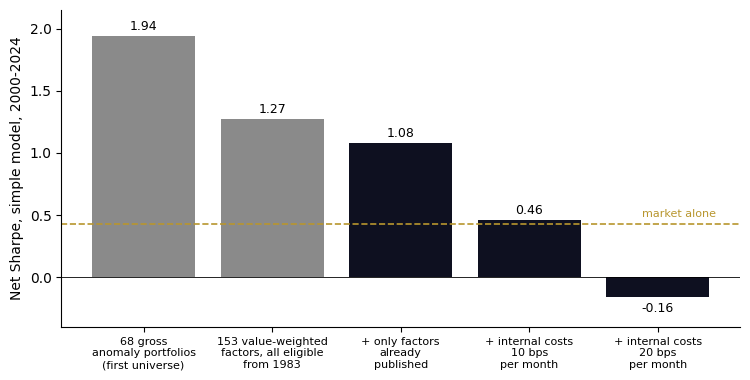

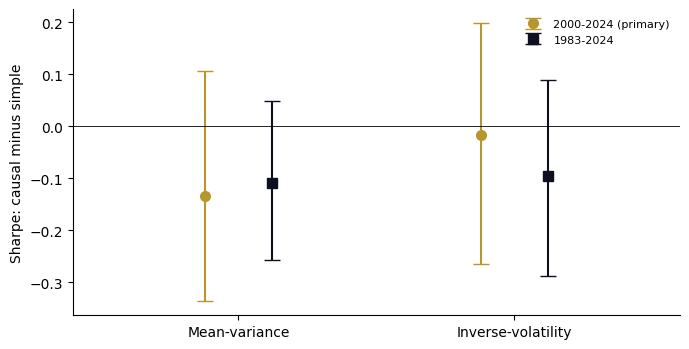

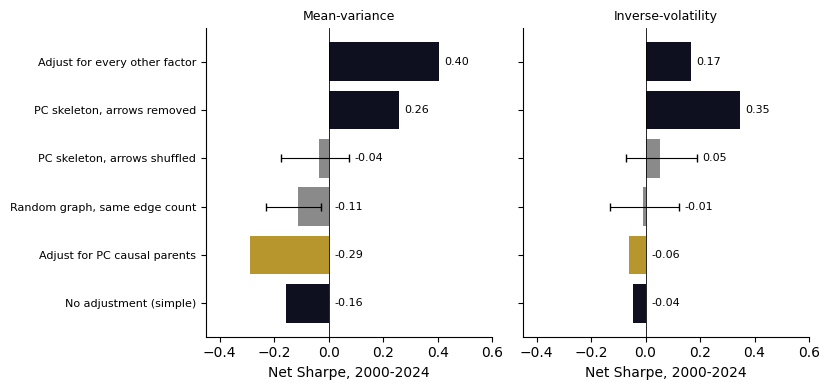

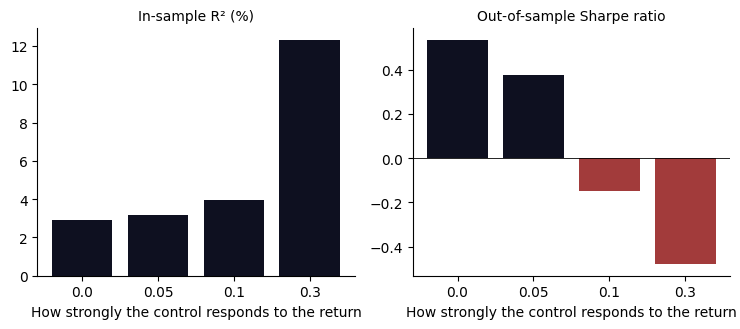

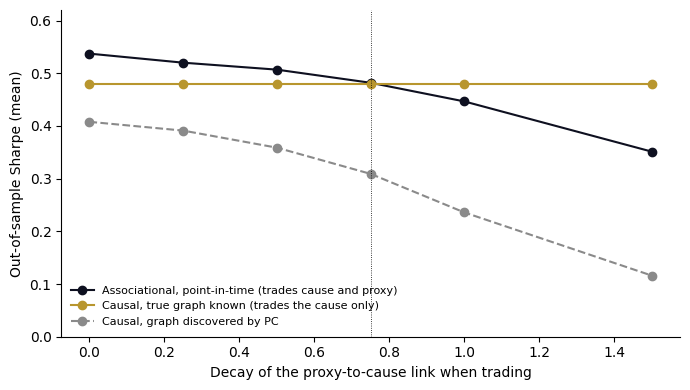

In [10]:
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False, 'figure.facecolor': 'white', 'savefig.dpi': 200})
NAVY, GOLD, GREY, RED = '#0E1020', '#B8962E', '#8A8A8A', '#A23B3B'
# Figure 1: realism ladder (simple model, 2000-2024)
simple = lambda F, name: cached(f'ladder_{name}', lambda: walk(F, model_fn('x', 'tstat', 240, 2, False)))
steps = [('68 gross\nanomaly portfolios\n(first universe)', sr(net(simple(U68, 'U68'), 20, 0)[m00])),
         ('153 value-weighted\nfactors, all eligible\nfrom 1983', sr(net(simple(J153, 'J153'), 20, 0)[m00])),
         ('+ only factors\nalready\npublished', SUMMARY[('MV', '2000-2024')]['SR_S_ic0']),
         ('+ internal costs\n10 bps\nper month', SUMMARY[('MV', '2000-2024')]['SR_S_ic10']),
         ('+ internal costs\n20 bps\nper month', SUMMARY[('MV', '2000-2024')]['SR_S_ic20'])]
fig, ax = plt.subplots(figsize=(7.6, 3.9))
for i, (nm, v) in enumerate(steps):
    ax.bar(i, v, color=[GREY, GREY, NAVY, NAVY, NAVY][i]); ax.text(i, v + 0.05 if v >= 0 else v - 0.12, f'{v:.2f}', ha='center', fontsize=9)
mk = SUMMARY[('MV', '2000-2024')]['MKT']; ax.axhline(mk, c=GOLD, lw=1.2, ls='--'); ax.text(4.45, mk + 0.05, 'market alone', color=GOLD, fontsize=8, ha='right')
ax.axhline(0, c='k', lw=0.6); ax.set_ylim(-0.4, 2.15); ax.set_xticks(range(5)); ax.set_xticklabels([s[0] for s in steps], fontsize=8)
ax.set_ylabel('Net Sharpe, simple model, 2000-2024'); fig.tight_layout(); fig.savefig(f'{FIG_DIR}/fig1_realism.png'); plt.show()
# Figure 2: causal minus simple
fig, ax = plt.subplots(figsize=(7, 3.6))
for i, ctor in enumerate(['MV', 'IV']):
    for j, (win, mk_, c) in enumerate([('2000-2024', 'o', GOLD), ('1983-2024', 's', NAVY)]):
        w = SUMMARY[(ctor, win)]
        ax.errorbar(i - 0.12 + 0.24 * j, w['d'], yerr=[[w['d'] - w['lo']], [w['hi'] - w['d']]], fmt=mk_, c=c, capsize=6, ms=7, label=(win + (' (primary)' if j == 0 else '')) if i == 0 else None)
ax.axhline(0, c='k', lw=0.6); ax.set_xticks([0, 1]); ax.set_xticklabels(['Mean-variance', 'Inverse-volatility']); ax.set_ylabel('Sharpe: causal minus simple')
ax.set_xlim(-0.6, 1.6); ax.legend(frameon=False, fontsize=8); fig.tight_layout(); fig.savefig(f'{FIG_DIR}/fig2_difference.png'); plt.show()
# Figure 3: attribution
fig, axs = plt.subplots(1, 2, figsize=(8.4, 4))
for i, ctor in enumerate(['MV', 'IV']):
    get = lambda nm: [sr(net(x)[m00]) for x in DIAG[ctor][nm]]
    rows = [('No adjustment (simple)', [sr(net(RES[ctor][PS])[m00])]), ('Adjust for PC causal parents', [sr(net(RES[ctor][PC])[m00])]),
            ('Random graph, same edge count', get('RDAG')), ('PC skeleton, arrows shuffled', get('RORIENT')),
            ('PC skeleton, arrows removed', get('NEIGH')), ('Adjust for every other factor', get('SPAN'))]
    x = axs[i]
    for j, (nm, v) in enumerate(rows):
        mm = np.median(v); x.barh(j, mm, color=GOLD if 'causal' in nm else (GREY if len(v) > 1 else NAVY))
        if len(v) > 1: x.errorbar(mm, j, xerr=[[mm - np.percentile(v, 5)], [np.percentile(v, 95) - mm]], c='k', capsize=3, lw=0.8)
        x.text(max(mm, np.percentile(v, 95) if len(v) > 1 else mm, 0) + 0.02, j, f'{mm:.2f}', va='center', fontsize=8)
    x.axvline(0, c='k', lw=0.6); x.set_xlim(-0.45, 0.6); x.set_yticks(range(len(rows))); x.set_yticklabels([r[0] for r in rows] if i == 0 else [], fontsize=8)
    x.set_title(['Mean-variance', 'Inverse-volatility'][i], fontsize=9); x.set_xlabel('Net Sharpe, 2000-2024')
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/fig3_attribution.png'); plt.show()
# Figures 4-5: control
fig, a = plt.subplots(1, 2, figsize=(7.5, 3.4))
a[0].bar(COLL.g_y.astype(str), COLL.R2 * 100, color=NAVY); a[0].set_title('In-sample R² (%)', fontsize=10)
a[1].bar(COLL.g_y.astype(str), COLL.SR_OOS, color=[NAVY if v > 0 else RED for v in COLL.SR_OOS]); a[1].axhline(0, c='k', lw=0.6); a[1].set_title('Out-of-sample Sharpe ratio', fontsize=10)
for x in a: x.set_xlabel('How strongly the control responds to the return')
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/fig4_control_collider.png'); plt.show()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(LABT.delta, LABT.ASSOC_PIT, '-o', c=NAVY, label='Associational, point-in-time (trades cause and proxy)')
ax.plot(LABT.delta, LABT.CAUSAL_ORACLE, '-o', c=GOLD, label='Causal, true graph known (trades the cause only)')
ax.plot(LABT.delta, LABT.CAUSAL_PC, '--o', c=GREY, label='Causal, graph discovered by PC')
ax.axvline(0.75, c='k', lw=0.6, ls=':'); ax.set_xlabel('Decay of the proxy-to-cause link when trading'); ax.set_ylabel('Out-of-sample Sharpe (mean)')
ax.set_ylim(0, 0.62); ax.legend(frameon=False, fontsize=8, loc='lower left'); fig.tight_layout(); fig.savefig(f'{FIG_DIR}/fig5_control_insurance.png'); plt.show()

## 10. Validation
Data integrity, point-in-time checks, an independent re-implementation, cost accounting, the fast PC against causal-learn, and the inference tools on synthetic data.

In [11]:
V = []
def check(name, ok, msg): V.append((name, 'PASS' if ok else 'FAIL', msg)); print(f"[{'PASS' if ok else 'FAIL'}] {name}: {msg}")
# data: official SAS build vs Python rebuild
P_ = pd.read_parquet(f'{DATA_DIR}/jkp_py.parquet'); P_['date'] = pd.to_datetime(P_['eom']).dt.to_period('M')
Wp = P_.pivot(index='date', columns='characteristic', values='ret_vw_cap'); Ws = JP.drop(columns=MKT).loc[:'2023-12']
cors = pd.Series({c: Ws[c].corr(Wp[c].reindex(Ws.index)) for c in Ws.columns if c in Wp.columns})
check('JKP SAS vs Python build', cors.min() > 0.95, f'{len(cors)} factors, median corr {cors.median():.4f}, min {cors.min():.4f}')
check('Mkt-RF alignment (Oct 1987)', JP.loc[pd.Period('1987-10', 'M'), MKT] < -0.2, f"{JP.loc[pd.Period('1987-10', 'M'), MKT]:.4f}")
known = {'market_equity': 1981, 'ret_12_1': 1993, 'ret_1_0': 1990, 'be_me': 1985, 'gp_at': 2013, 'at_gr1': 2008, 'ivol_ff3_21d': 2006}
check('publication years of known factors', all(PUB.get(k) == v for k, v in known.items()), str({k: PUB.get(k) for k in known}))
viol = sum(1 for ctor in RES for k, r in RES[ctor].items() for d, w in r['w'].items() for c in w.index if c != MKT and PUB.get(c, 9999) > d.year - 1)
check('no factor held before publication', viol == 0, f'{viol} violations')
# truncation test: delete all data after the rebalance and re-estimate
diffs = []
for d in [REBAL[i] for i in (17, 25, 33, 41)]:
    Ft = JP.loc[:d]; win = Ft.loc[d - 239:d]; elig = [c for c in win.columns if win[c].notna().all() and pub_elig(c, d)]; R = win[elig].values
    for key, sel in [(PS, tstat_select(R, 2, False)), (PC, dag_select(R, pc_fast((R - R.mean(0)) / R.std(0), 0.05, 3, exo=elig.index(MKT))))]:
        ws = pd.Series(mv_long_only(R[:, sel].mean(0), lw_cov(R[:, sel])), index=[elig[i] for i in sel]); ws = ws[ws != 0]
        diffs.append(float((ws.reindex(RES['MV'][key]['w'][d].index).fillna(0) - RES['MV'][key]['w'][d]).abs().max()))
check('truncation test (no future data)', max(diffs) < 1e-10, f'max weight diff {max(diffs):.1e}')
# independent re-implementation of the simple model with a different optimiser
g = pd.Series(0.0, index=OOS)
for d in REBAL:
    win = JP.loc[d - 239:d]; elig = [c for c in win.columns if win[c].notna().all() and pub_elig(c, d)]; Xw = win[elig]
    t = Xw.mean() / (Xw.std(ddof=1) / np.sqrt(len(Xw))); sel = list(t[t > 2].index)
    if not sel: continue
    mu = Xw[sel].mean().values; Sg = lw_cov(Xw[sel].values)
    w = minimize(lambda w: -(mu @ w - 0.5 * w @ Sg @ w), np.full(len(sel), 0.1), jac=lambda w: -(mu - Sg @ w), bounds=[(0, None)] * len(sel), method='L-BFGS-B', options=dict(maxiter=5000, ftol=1e-15, gtol=1e-12)).x
    w *= VOL_TGT / np.sqrt(w @ Sg @ w); hold = pd.period_range(d + 1, min(d + 12, OOS[-1]), freq='M'); g.loc[hold] = JP.loc[hold, sel].fillna(0).values @ w
c_ = np.corrcoef(g, RES['MV'][PS]['gross'])[0, 1]; check('independent re-implementation', c_ > 0.999, f'corr {c_:.5f}')
# cost accounting by hand for one year
r_ = RES['MV'][PS]; d = REBAL[30]; hold = pd.period_range(d + 1, d + 12, freq='M')
man = r_['gross'].loc[hold].copy(); man.iloc[0] -= 0.002 * r_['turn'][d]; man -= 0.002 * r_['w'][d].drop(MKT, errors='ignore').abs().sum()
check('cost accounting', np.allclose(man, net(r_).loc[hold]), f'max diff {np.abs(man - net(r_).loc[hold]).max():.1e}')
# fast PC vs causal-learn on two realistic windows
ok = []
for d in [pd.Period('2000-06', 'M'), pd.Period('2004-06', 'M')]:
    win = JP.loc[d - 239:d]; elig = [c for c in win.columns if win[c].notna().all() and pub_elig(c, d)]; Z = win[elig].values; Z = (Z - Z.mean(0)) / Z.std(0)
    nodes = [GraphNode(f'X{i + 1}') for i in range(Z.shape[1])]; bk = BackgroundKnowledge(); mi = elig.index(MKT)
    for j in range(Z.shape[1]):
        if j != mi: bk.add_forbidden_by_node(nodes[j], nodes[mi])
    ok.append(bool((pc(Z, 0.05, 'fisherz', background_knowledge=bk, show_progress=False, max_k=3).G.graph == pc_fast(Z, 0.05, 3, exo=mi)).all()))
check('fast PC identical to causal-learn', all(ok), str(ok))
# inference tools on synthetic data
rng = np.random.default_rng(3); noise = rng.standard_normal((294, 20)) * 0.03; sig = noise.copy(); sig[:, 0] += 0.03 / np.sqrt(12)
p0, p1 = cscv(noise), cscv(sig); d0_ = dsr(noise[:, np.argmax(noise.mean(0))], [sr(noise[:, j], False) for j in range(20)])[0]
check('PBO/DSR sanity', 0.3 < p0 < 0.8 and p1 < 0.2 and d0_ < 0.95, f'noise PBO {p0:.2f}, DSR {d0_:.2f}; true SR=1 strategy PBO {p1:.2f}')
for ctor in ('MV', 'IV'):
    c1, s1 = net(RES[ctor][PC])[m00].values, net(RES[ctor][PS])[m00].values
    cis = [boot_dsr(c1, s1, B=4000, mean_block=b, seed=11) for b in (1, 6, 24)]
    check(f'CI stable across block lengths ({ctor})', all(lo < 0 < hi for _, lo, hi, _ in cis), '; '.join(f'[{lo:+.2f},{hi:+.2f}]' for _, lo, hi, _ in cis))

[PASS] JKP SAS vs Python build: 142 factors, median corr 1.0000, min 0.9970
[PASS] Mkt-RF alignment (Oct 1987): -0.2319
[PASS] publication years of known factors: {'market_equity': 1981.0, 'ret_12_1': 1993.0, 'ret_1_0': 1990.0, 'be_me': 1985.0, 'gp_at': 2013.0, 'at_gr1': 2008.0, 'ivol_ff3_21d': 2006.0}
[PASS] no factor held before publication: 0 violations


[PASS] truncation test (no future data): max weight diff 0.0e+00


[PASS] independent re-implementation: corr 1.00000
[PASS] cost accounting: max diff 0.0e+00


[PASS] fast PC identical to causal-learn: [True, True]


[PASS] PBO/DSR sanity: noise PBO 0.52, DSR 0.53; true SR=1 strategy PBO 0.00
[PASS] CI stable across block lengths (MV): [-0.36,+0.11]; [-0.35,+0.10]; [-0.32,+0.11]


[PASS] CI stable across block lengths (IV): [-0.25,+0.22]; [-0.26,+0.23]; [-0.28,+0.17]


## 11. Audit of the article's numbers
Every number quoted in the article, compared with what this notebook just computed, rounded to the precision the article prints. With `FAST = True` only the primary-pair numbers are audited.

In [12]:
a, b = SUMMARY[('MV', '2000-2024')], SUMMARY[('IV', '2000-2024')]
at = lambda ctor, nm: ATTR.set_index(['ctor', 'diag']).loc[(ctor, nm)]
claims = [('simple MV no internal cost', 1.08, a['SR_S_ic0']), ('causal MV no internal cost', 0.90, a['SR_C_ic0']), ('simple MV 10 bps', 0.46, a['SR_S_ic10']),
          ('causal MV 10 bps', 0.31, a['SR_C_ic10']), ('simple MV 20 bps', -0.16, a['SR_S_ic20']), ('causal MV 20 bps', -0.29, a['SR_C_ic20']),
          ('simple IV no internal cost', 0.74, b['SR_S_ic0']), ('causal IV no internal cost', 0.69, b['SR_C_ic0']), ('simple IV 10 bps', 0.35, b['SR_S_ic10']),
          ('causal IV 10 bps', 0.31, b['SR_C_ic10']), ('simple IV 20 bps', -0.04, b['SR_S_ic20']), ('causal IV 20 bps', -0.06, b['SR_C_ic20']),
          ('MV difference', -0.13, a['d']), ('IV difference', -0.02, b['d']), ('market 2000-2024', 0.43, a['MKT']), ('EW gross', 0.57, a['EW_gross']), ('EW net', 0.11, a['EW']),
          ('ladder: first universe', 1.94, steps[0][1]), ('ladder: JKP all eligible', 1.27, steps[1][1])]
if not FAST:
    claims += [('MV CI low', -0.34, a['lo']), ('MV CI high', 0.11, a['hi']), ('IV CI low', -0.26, b['lo']), ('IV CI high', 0.20, b['hi']),
               ('MV matched wins', 10, a['pairs_win']), ('IV matched wins', 12, b['pairs_win']), ('MV DSR switch', 0.31, a['dsr_switch']), ('IV DSR switch', 0.60, b['dsr_switch']),
               ('MV PBO', 0.63, a['pbo']), ('IV PBO', 0.29, b['pbo']), ('MV turnover ratio', 1.5, a['turn_ratio']), ('IV turnover ratio', 1.8, b['turn_ratio']),
               ('MV 1983-2024 difference', -0.11, SUMMARY[('MV', '1983-2024')]['d']), ('IV 1983-2024 difference', -0.10, SUMMARY[('IV', '1983-2024')]['d']),
               ('MV random-set pct', 0.38, at('MV', 'RANDK')['causal_pct']), ('IV random-set pct', 0.79, at('IV', 'RANDK')['causal_pct']),
               ('MV shuffled-arrows median', -0.04, at('MV', 'RORIENT')['median']), ('MV shuffled-arrows pct', 0.0, at('MV', 'RORIENT')['causal_pct']),
               ('MV random-graph median', -0.11, at('MV', 'RDAG')['median']), ('IV random-graph median', -0.01, at('IV', 'RDAG')['median']),
               ('MV arrows removed', 0.26, at('MV', 'NEIGH')['median']), ('IV arrows removed', 0.35, at('IV', 'NEIGH')['median']),
               ('MV all-factor adjustment', 0.40, at('MV', 'SPAN')['median']), ('IV all-factor adjustment', 0.17, at('IV', 'SPAN')['median']),
               ('MV oriented parents only', -0.23, at('MV', 'DIRONLY')['median']), ('IV oriented parents only', -0.04, at('IV', 'DIRONLY')['median']),
               ('control: PIT Sharpe, stable', 0.537, LABT.ASSOC_PIT[0]), ('control: oracle Sharpe, stable', 0.480, LABT.CAUSAL_ORACLE[0]),
               ('control: canon Sharpe', -0.15, LABT.CANON[0]), ('control: canon R2', 0.040, LAB.r2_canon.mean()), ('control: assoc R2', 0.027, LAB.r2_assoc.mean()),
               ('control: sign flip share', 0.97, np.mean([b_[0] < 0 for b_ in LAB.b_canon])), ('control: strong collider R2', 0.123, COLL.R2.iloc[-1]),
               ('control: strong collider Sharpe', -0.48, COLL.SR_OOS.iloc[-1])]
def dp(v):
    t = repr(float(v)); return 0 if float(v).is_integer() else len(t.split('.')[1])
AUD = pd.DataFrame([dict(claim=n, article=v, computed=round(float(c), 4), ok=abs(round(float(c), dp(v)) - v) < 1e-9) for n, v, c in claims])
print(f"{AUD.ok.sum()} of {len(AUD)} numbers match; total runtime {(time.time() - T0) / 60:.1f} min")
AUD[~AUD.ok] if (~AUD.ok).any() else AUD.tail(3)

53 of 53 numbers match; total runtime 2.4 min


,claim,article,computed,ok
50,control: sign flip share,0.970,0.970,True
51,control: strong collider R2,0.123,0.123,True
52,control: strong collider Sharpe,-0.480,-0.481,True
